In [2]:
import pytbl
import panel
import pandas as pd
import warnings
import numpy as np
from datetime import datetime
from tqdm import tqdm
from joblib import Parallel, delayed
from concurrent.futures import ThreadPoolExecutor
from IPython import get_ipython
from IPython.display import display, Javascript
from IPython import get_ipython
from IPython import get_ipython
ip = get_ipython()
path = None
if '__vsc_ipynb_file__' in ip.user_ns:
    path = ip.user_ns['__vsc_ipynb_file__']
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
warnings.filterwarnings("ignore")
begDate    = "20200130"
endData    = "20201123"
sampleDate = "20210421"

from busdates import PortableBusDates
from tqdm import tqdm
pbd = PortableBusDates()
tradingdays = pbd.get_range(begDate, endData)
nodatelist = pbd.get_range("20201123", "20210421")
preface_tradingdays = pbd.get_range(pbd.prev_date(begDate, 122), begDate) + tradingdays
alpha_name = 'timedelay_verystrict'# path.split('.')[0].split('/')[-1]

In [ ]:
# root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
# sample_1min_df = pytbl.tbl_read(f"{root_dir}{alpha_name}/{20250401}.tbl")
# sample_1min_df['timeHMSf'] = sample_1min_df['rec_epoch'].apply(lambda timestamp: datetime.fromtimestamp(timestamp).strftime("%H:%M:%S.%f"))
# sample_1min_df.set_index(['sid','timeHMSf'], inplace=True)
# sample_1min_df.sort_index().head(200)

In [3]:

# sampleDate = "20240409"
root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
def loadingfeaturetbl(sampleDate, alpha_name):
    # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
    sample_1min_df = panel.sdiv2df(
        panel.read(f"{root_dir}{alpha_name}/terms.{sampleDate}.sdiv")
    )
    return sample_1min_df


Process_1min_df = Parallel(n_jobs=100, verbose=10)(
    delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
)
feature_1min_df = pd.concat(Process_1min_df, ignore_index=True)
feature_1min_df = feature_1min_df.reset_index()
feature_1min_df['sid'] = feature_1min_df['sid'].astype(int).astype(str)
feature_1min_df = feature_1min_df.set_index(['sid','date','time']).sort_index()

100%|██████████| 199/199 [00:01<00:00, 128.09it/s]
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    6.1s
[Parallel(n_jobs=100)]: Done  20 out of 199 | elapsed:    6.5s remaining:   58.6s
[Parallel(n_jobs=100)]: Done  40 out of 199 | elapsed:    7.0s remaining:   27.8s
[Parallel(n_jobs=100)]: Done  60 out of 199 | elapsed:    7.4s remaining:   17.2s
[Parallel(n_jobs=100)]: Done  80 out of 199 | elapsed:    7.8s remaining:   11.6s
[Parallel(n_jobs=100)]: Done 100 out of 199 | elapsed:    8.2s remaining:    8.1s
[Parallel(n_jobs=100)]: Done 120 out of 199 | elapsed:    8.6s remaining:    5.7s
[Parallel(n_jobs=100)]: Done 140 out of 199 | elapsed:    9.0s remaining:    3.8s
[Parallel(n_jobs=100)]: Done 160 out of 199 | elapsed:    9.4s remaining:    2.3s
[Parallel(n_jobs=100)]: Done 180 out of 199 | elapsed:    9.8s remaining:    1.0s
[Parallel(n_jobs=100)]: Done 199 out of 199 | elapsed:   10.1s finished


In [ ]:
# univ = 'midx'
# label_dir = '/data/beer2/data/CA.LTS/CNEQ/Panels/'
# def load_labels_1min(sampleDate, univ):
#     Omin_label = panel.sdiv2df(
#         panel.read(f"{label_dir}Y/Y_v5_1min/terms.{sampleDate}.sdiv").sel(V=slice('ret1h','ret0e'))
#     )
#     active = panel.sdiv2df(
#         panel.read(f"{label_dir}I/fq1m/BB/terms.{sampleDate}.sdiv").sel(V=slice('is.active','is.active'))
#     )
#     univ = panel.sdiv2df(
#         panel.read(f"{label_dir}D/bod/univ/univ-{sampleDate}.sdiv").sel(V=slice(f"{univ}", f"{univ}"))
#     )
#     return Omin_label, active, univ
# Process_label_df = Parallel(n_jobs=100, verbose=10)(
#     delayed(load_labels_1min)(sampleDate, univ) for sampleDate in tqdm(tradingdays)
# )
# label_df  = pd.concat([Process[0] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# weight_df = pd.concat([Process[1] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# univ_df   = pd.concat([Process[2] for Process in Process_label_df], ignore_index=True).set_index(['sid','date'])

# label_df = label_df.merge(weight_df[['is.active']], left_index=True, right_index=True, how='left')
# label_df = label_df.merge(univ_df, left_index=True, right_index=True, how='left')
# label_df = label_df[label_df[f'{univ}']>0]

# label_df['ret0e_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret0e'].shift(-1)
# label_df['ret1h_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret1h'].shift(-1)
# label_df.to_parquet("/data/nfshome/wensheng/git/wensheng_jawN9J/label_df.parquet", engine="pyarrow", compression="snappy")

In [ ]:
# # sampleDate = "20240409"
# root_dir = '/data/nfs0/chinaEquityData/panel/'
# def loadingfeaturetbl(sampleDate, alpha_name):
#     # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
#     sample_1min_df = panel.sdiv2df(
#         panel.read(f"{root_dir}5min/5min-{sampleDate}.sdiv").sel(V = slice("midPriceLastValid", "close.avg"))
#     )
#     return sample_1min_df


# Process_1min_df_2 = Parallel(n_jobs=100, verbose=10)(
#     delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
# )
# feature_1min_df_2 = pd.concat(Process_1min_df_2, ignore_index=True)
# feature_1min_df_2 = feature_1min_df_2.set_index(['sid','date','time'])

In [5]:
feature_1min_df.columns

Index(['index', 'Sum_filteract_B_delayl_addQ', 'Sum_filteract_B_Ratiosl_addQ',
       'Sum_filteract_S_delayl_addQ', 'Sum_filteract_S_Ratiosl_addQ',
       'Std_filteract_B_delayl_addQ', 'Std_filteract_B_Ratiosl_addQ',
       'Std_filteract_S_delayl_addQ', 'Std_filteract_S_Ratiosl_addQ',
       'Qtyadd_all', 'Qtyrealadd_all', 'Qtytrd_all'],
      dtype='object')

In [7]:
label_df = pd.read_feather("/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/label_df_2020_202011.feather")


feature_1min_df['Sum_filteract_B_delayl_addQ_divall'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Sum_filteract_S_delayl_addQ_divall'] = (feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Sum_filteract_B_delayl_addQ_divall_real'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Sum_filteract_S_delayl_addQ_divall_real'] = (feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Sum_filteract_B_delayl_addQ_divall_trd'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] ) / (feature_1min_df['Qtytrd_all'] ) 
feature_1min_df['Sum_filteract_S_delayl_addQ_divall_trd'] = (feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtytrd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSdivall'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] - feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSadddivall'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] + feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSdivall_real'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] - feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSadddivall_real'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] + feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSdivall_trd'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] - feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtytrd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSadddivall_trd'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] + feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtytrd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSratio'] = (feature_1min_df['Sum_filteract_B_delayl_addQ'] - feature_1min_df['Sum_filteract_S_delayl_addQ'] ) / (feature_1min_df['Sum_filteract_B_delayl_addQ'] + feature_1min_df['Sum_filteract_S_delayl_addQ'] )


feature_1min_df['Std_filteract_B_delayl_addQ_divall'] = (feature_1min_df['Std_filteract_B_delayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteract_S_delayl_addQ_divall'] = (feature_1min_df['Std_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteract_B_delayl_addQ_divall_real'] = (feature_1min_df['Std_filteract_B_delayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Std_filteract_S_delayl_addQ_divall_real'] = (feature_1min_df['Std_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Std_filteractdelayl_addQ_BSdivall'] = (feature_1min_df['Std_filteract_B_delayl_addQ'] - feature_1min_df['Std_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteractdelayl_addQ_BSratio'] = (feature_1min_df['Std_filteract_B_delayl_addQ'] - feature_1min_df['Std_filteract_S_delayl_addQ'] ) / (feature_1min_df['Sum_filteract_B_delayl_addQ'] + feature_1min_df['Sum_filteract_S_delayl_addQ'] )
feature_1min_df['Std_filteractdelayl_addQ_BSratiostd'] = (feature_1min_df['Std_filteract_B_delayl_addQ'] - feature_1min_df['Std_filteract_S_delayl_addQ'] ) / (feature_1min_df['Std_filteract_B_delayl_addQ'] + feature_1min_df['Std_filteract_S_delayl_addQ'] )
feature_1min_df['Std_filteractdelayl_addQ_BSadddivall'] = (feature_1min_df['Std_filteract_B_delayl_addQ'] + feature_1min_df['Std_filteract_S_delayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 







feature_1min_df['Sum_filteract_B_Ratiosl_addQ_divall'] = (feature_1min_df['Sum_filteract_B_Ratiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Sum_filteract_S_Ratiosl_addQ_divall'] = (feature_1min_df['Sum_filteract_S_Ratiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractRatiosl_addQ_BSdivall'] = (feature_1min_df['Sum_filteract_B_Ratiosl_addQ'] - feature_1min_df['Sum_filteract_S_Ratiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractRatiosl_addQ_BSratio'] = (feature_1min_df['Sum_filteract_B_Ratiosl_addQ'] - feature_1min_df['Sum_filteract_S_Ratiosl_addQ'] ) / (feature_1min_df['Sum_filteract_B_Ratiosl_addQ'] + feature_1min_df['Sum_filteract_S_Ratiosl_addQ'] )
feature_1min_df['Mean_filteractRatiosl_addQ_BSadddivall'] = (feature_1min_df['Sum_filteract_B_Ratiosl_addQ'] + feature_1min_df['Sum_filteract_S_Ratiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 

feature_1min_df['Std_filteract_B_Ratiosl_addQ_divall'] = (feature_1min_df['Std_filteract_B_Ratiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteract_S_Ratiosl_addQ_divall'] = (feature_1min_df['Std_filteract_S_Ratiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteractRatiosl_addQ_BSdivall'] = (feature_1min_df['Std_filteract_B_Ratiosl_addQ'] - feature_1min_df['Std_filteract_S_Ratiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteractRatiosl_addQ_BSratio'] = (feature_1min_df['Std_filteract_B_Ratiosl_addQ'] - feature_1min_df['Std_filteract_S_Ratiosl_addQ'] ) / (feature_1min_df['Sum_filteract_B_Ratiosl_addQ'] + feature_1min_df['Sum_filteract_S_Ratiosl_addQ'] )
feature_1min_df['Std_filteractRatiosl_addQ_BSratiostd'] = (feature_1min_df['Std_filteract_B_Ratiosl_addQ'] - feature_1min_df['Std_filteract_S_Ratiosl_addQ'] ) / (feature_1min_df['Std_filteract_B_Ratiosl_addQ'] + feature_1min_df['Std_filteract_S_Ratiosl_addQ'] )
feature_1min_df['Std_filteractRatiosl_addQ_BSadddivall'] = (feature_1min_df['Std_filteract_B_Ratiosl_addQ'] + feature_1min_df['Std_filteract_S_Ratiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 






In [ ]:
# feature_1min_df['close.avg'] = feature_1min_df_2['close.avg']
# feature_1min_df['close']     = feature_1min_df_2['close']
# feature_1min_df['avg_minus_close'] = (feature_1min_df['close.avg'] - feature_1min_df['close']) / feature_1min_df['close']

In [8]:
feature_all_df = feature_1min_df.merge(label_df[['ret1h','ret0e','is.active','ret0e_shift','ret1h_shift']], left_index=True, right_index=True, how='inner')
feature_all_df = feature_all_df[(feature_all_df['is.active']>0)]

In [13]:
feature_all_df = feature_all_df.replace(np.inf, np.nan).replace(-np.inf, np.nan)

In [14]:
feature_all_df[['Sum_filteract_B_delayl_addQ_divall' ,'Sum_filteract_S_delayl_addQ_divall' ,'Sum_filteract_B_delayl_addQ_divall_real' ,
                'Sum_filteract_S_delayl_addQ_divall_real' ,'Sum_filteract_B_delayl_addQ_divall_trd' ,'Sum_filteract_S_delayl_addQ_divall_trd' ,'Mean_filteractdelayl_addQ_BSdivall' ,'Mean_filteractdelayl_addQ_BSadddivall' ,'Mean_filteractdelayl_addQ_BSdivall_real' ,'Mean_filteractdelayl_addQ_BSadddivall_real' ,'Mean_filteractdelayl_addQ_BSdivall_trd' ,'Mean_filteractdelayl_addQ_BSadddivall_trd' ,'Mean_filteractdelayl_addQ_BSratio' ,'Std_filteract_B_delayl_addQ_divall' ,'Std_filteract_S_delayl_addQ_divall' ,'Std_filteract_B_delayl_addQ_divall_real' ,'Std_filteract_S_delayl_addQ_divall_real' ,'Std_filteractdelayl_addQ_BSdivall' ,'Std_filteractdelayl_addQ_BSratio' ,'Std_filteractdelayl_addQ_BSratiostd' ,'Std_filteractdelayl_addQ_BSadddivall' ,'Sum_filteract_B_Ratiosl_addQ_divall' ,'Sum_filteract_S_Ratiosl_addQ_divall' ,'Mean_filteractRatiosl_addQ_BSdivall' ,'Mean_filteractRatiosl_addQ_BSratio' ,'Mean_filteractRatiosl_addQ_BSadddivall' ,'Std_filteract_B_Ratiosl_addQ_divall' ,'Std_filteract_S_Ratiosl_addQ_divall' ,'Std_filteractRatiosl_addQ_BSdivall' ,'Std_filteractRatiosl_addQ_BSratio' ,'Std_filteractRatiosl_addQ_BSratiostd' ,'Std_filteractRatiosl_addQ_BSadddivall' ]].describe()

,Sum_filteract_B_delayl_addQ_divall,Sum_filteract_S_delayl_addQ_divall,Sum_filteract_B_delayl_addQ_divall_real,Sum_filteract_S_delayl_addQ_divall_real,Sum_filteract_B_delayl_addQ_divall_trd,Sum_filteract_S_delayl_addQ_divall_trd,Mean_filteractdelayl_addQ_BSdivall,Mean_filteractdelayl_addQ_BSadddivall,Mean_filteractdelayl_addQ_BSdivall_real,Mean_filteractdelayl_addQ_BSadddivall_real,Mean_filteractdelayl_addQ_BSdivall_trd,Mean_filteractdelayl_addQ_BSadddivall_trd,Mean_filteractdelayl_addQ_BSratio,Std_filteract_B_delayl_addQ_divall,Std_filteract_S_delayl_addQ_divall,Std_filteract_B_delayl_addQ_divall_real,Std_filteract_S_delayl_addQ_divall_real,Std_filteractdelayl_addQ_BSdivall,Std_filteractdelayl_addQ_BSratio,Std_filteractdelayl_addQ_BSratiostd,Std_filteractdelayl_addQ_BSadddivall,Sum_filteract_B_Ratiosl_addQ_divall,Sum_filteract_S_Ratiosl_addQ_divall,Mean_filteractRatiosl_addQ_BSdivall,Mean_filteractRatiosl_addQ_BSratio,Mean_filteractRatiosl_addQ_BSadddivall,Std_filteract_B_Ratiosl_addQ_divall,Std_filteract_S_Ratiosl_addQ_divall,Std_filteractRatiosl_addQ_BSdivall,Std_filteractRatiosl_addQ_BSratio,Std_filteractRatiosl_addQ_BSratiostd,Std_filteractRatiosl_addQ_BSadddivall
count,1.136852e+07,1.136852e+07,1.137051e+07,1.137051e+07,1.135835e+07,1.135835e+07,1.136852e+07,1.136852e+07,1.137051e+07,1.137051e+07,1.135835e+07,1.135835e+07,1.126436e+07,1.136852e+07,1.136852e+07,1.137051e+07,1.137051e+07,1.136852e+07,1.126436e+07,1.081747e+07,1.136852e+07,1.136852e+07,1.136852e+07,1.136852e+07,1.060394e+07,1.136852e+07,1.136852e+07,1.136852e+07,1.136852e+07,1.060394e+07,1.024263e+07,1.136852e+07
mean,3.313200e-01,6.168864e-01,2.737430e-01,5.004624e-01,8.182202e-01,1.417266e+00,-2.855663e-01,9.482064e-01,-2.267195e-01,7.742054e-01,-5.990460e-01,2.235486e+00,-1.627161e-01,1.413066e-02,1.974472e-02,1.160363e-02,1.597709e-02,-5.614061e-03,-6.695437e-03,-1.154971e-01,3.387538e-02,3.229187e-01,3.626400e-01,-3.972128e-02,7.885431e-02,6.855588e-01,1.249665e-02,1.285441e-02,-3.577576e-04,6.322316e-03,9.336989e-02,2.535106e-02
std,1.067383e+00,2.279795e+00,7.485958e-01,1.314690e+00,1.897846e+00,3.084905e+00,2.535764e+00,2.498689e+00,1.537737e+00,1.487607e+00,3.728117e+00,3.512557e+00,6.487248e-01,3.096657e-02,3.739788e-02,1.850961e-02,2.321162e-02,4.879093e-02,7.323796e-02,6.304894e-01,4.831672e-02,6.364679e-01,8.004105e-01,1.029948e+00,8.475745e-01,1.015236e+00,2.446951e-02,2.941016e-02,3.771713e-02,6.992296e-02,8.378425e-01,3.879236e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.161111e+03,0.000000e+00,-1.616835e+02,0.000000e+00,-2.754124e+02,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.677840e+01,-5.773503e-01,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.564540e+02,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.447171e+01,-5.757270e-01,-1.000000e+00,0.000000e+00
25%,4.577611e-02,7.656968e-02,4.044682e-02,6.780878e-02,1.454006e-01,2.521334e-01,-3.601188e-01,2.207754e-01,-3.112066e-01,1.962077e-01,-1.007910e+00,7.218045e-01,-7.705743e-01,2.381659e-03,3.607830e-03,2.139782e-03,3.238741e-03,-1.403830e-02,-2.608531e-02,-6.780708e-01,1.111398e-02,0.000000e+00,0.000000e+00,-2.729216e-01,-9.507964e-01,1.578947e-01,0.000000e+00,0.000000e+00,-8.394315e-03,-2.011069e-02,-1.000000e+00,5.384412e-03
50%,1.181737e-01,1.994807e-01,1.031977e-01,1.740196e-01,3.512444e-01,5.905975e-01,-5.571463e-02,4.528416e-01,-4.977244e-02,3.931530e-01,-1.967655e-01,1.292994e+00,-2.760736e-01,6.440558e-03,9.401833e-03,5.666417e-03,8.287762e-03,-1.560090e-03,-3.588635e-03,-1.806228e-01,2.168161e-02,1.493042e-01,1.184352e-01,0.000000e+00,1.453287e-01,3.972463e-01,5.517667e-03,4.167193e-03,0.000000e+00,2.054025e-03,1.613848e-01,1.414596e-02
75%,2.877945e-01,5.171308e-01,2.467094e-01,4.424443e-01,7.975266e-01,1.386004e+00,1.030641e-01,9.447115e-01,9.079229e-02,8.024054e-01,3.351351e-01,2.431957e+00,4.141545e-01,1.562704e-02,2.242174e-02,1.342877e-02,1.926016e-02,5.963111e-03,1.372528e-0

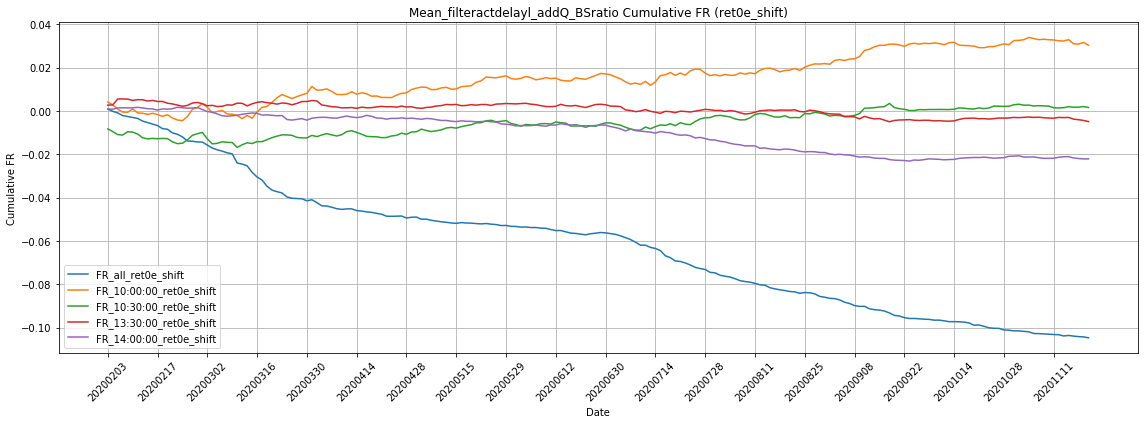

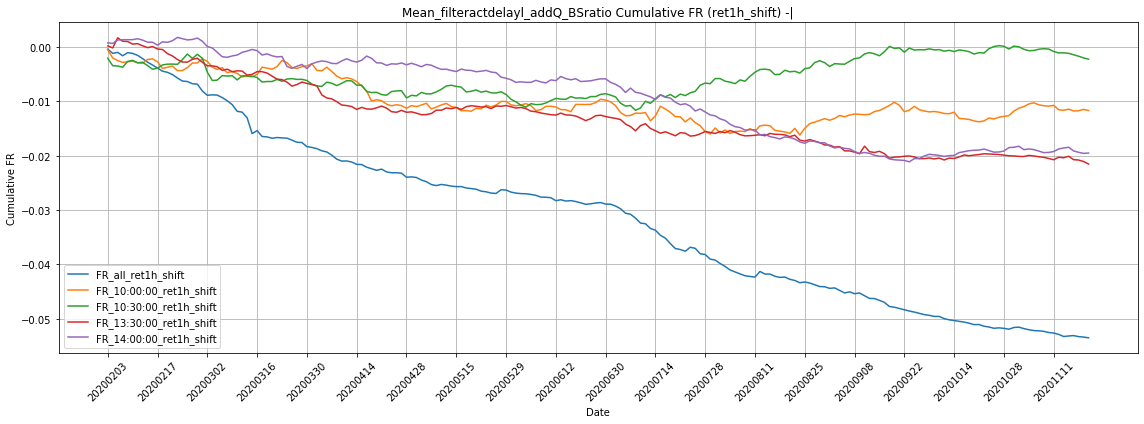

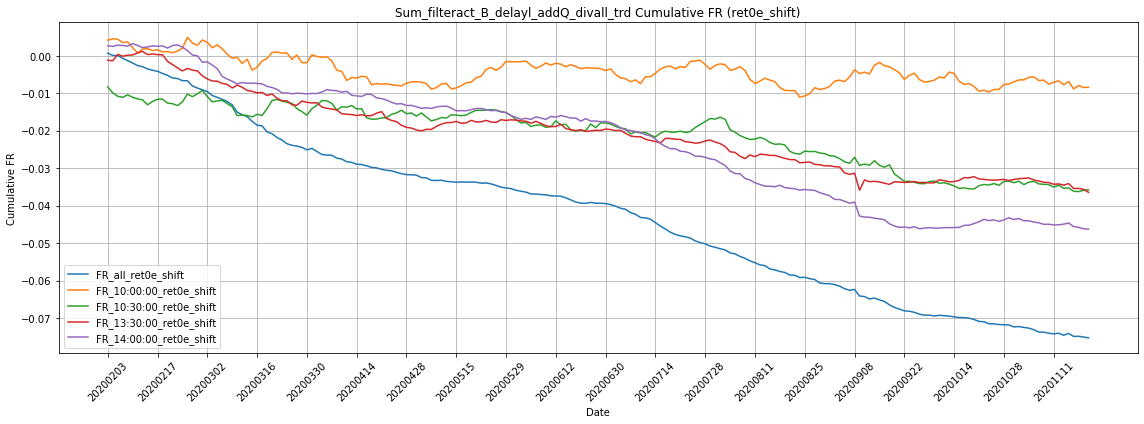

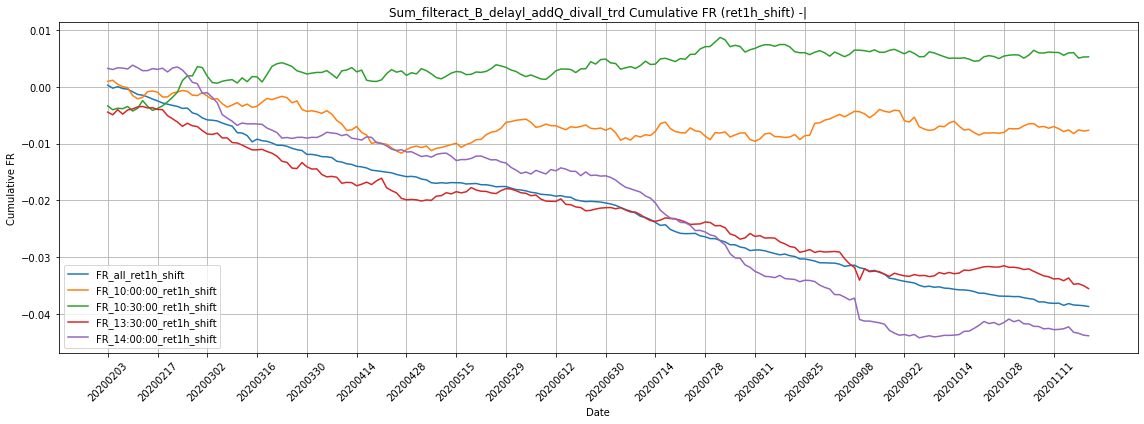

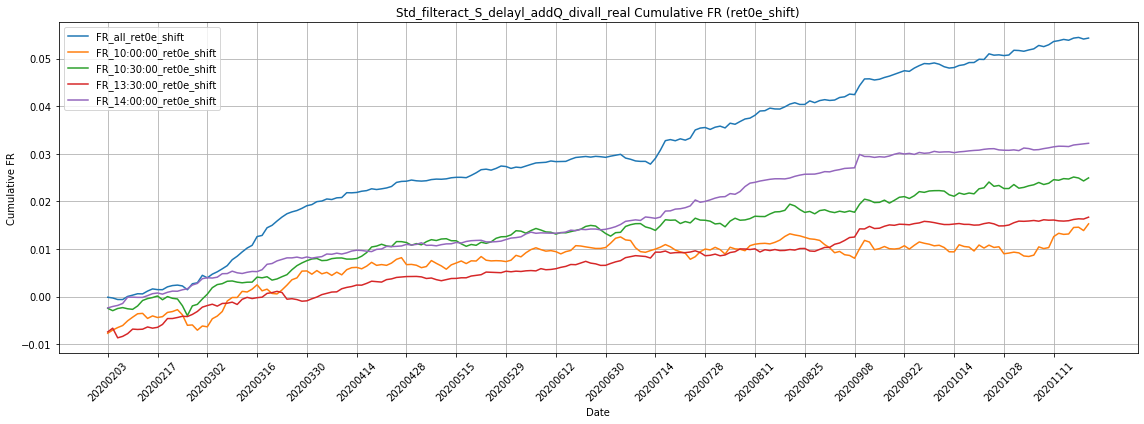

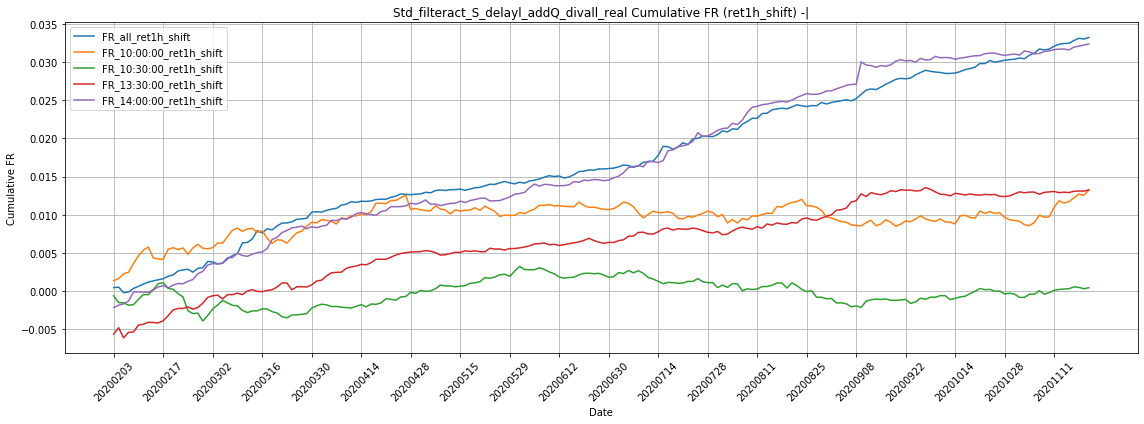

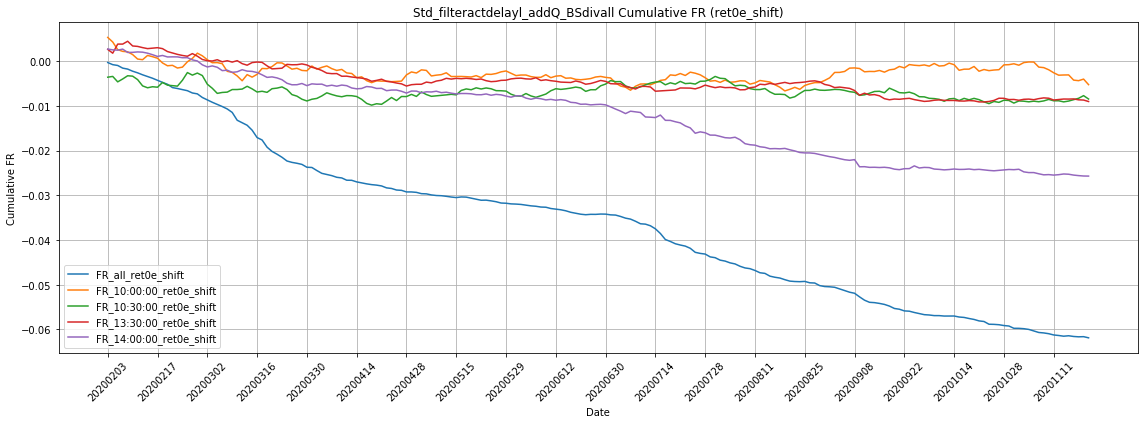

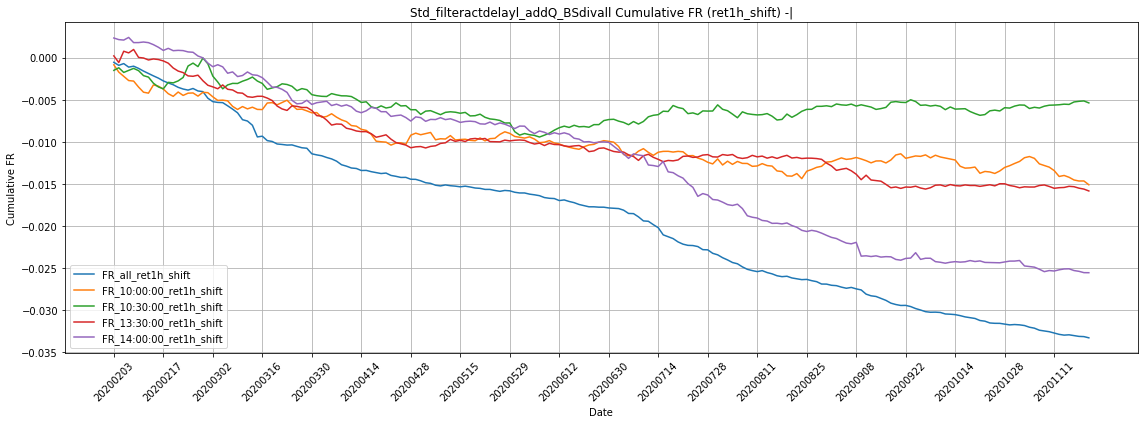

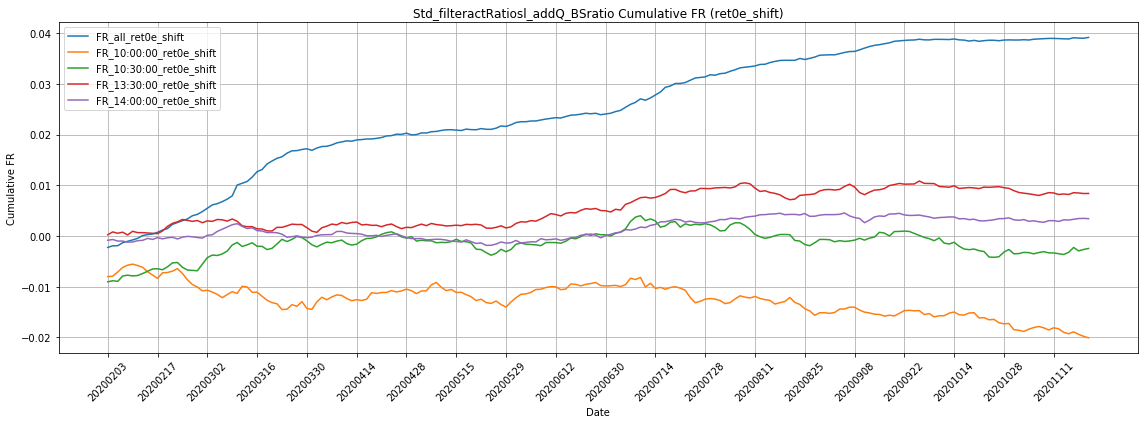

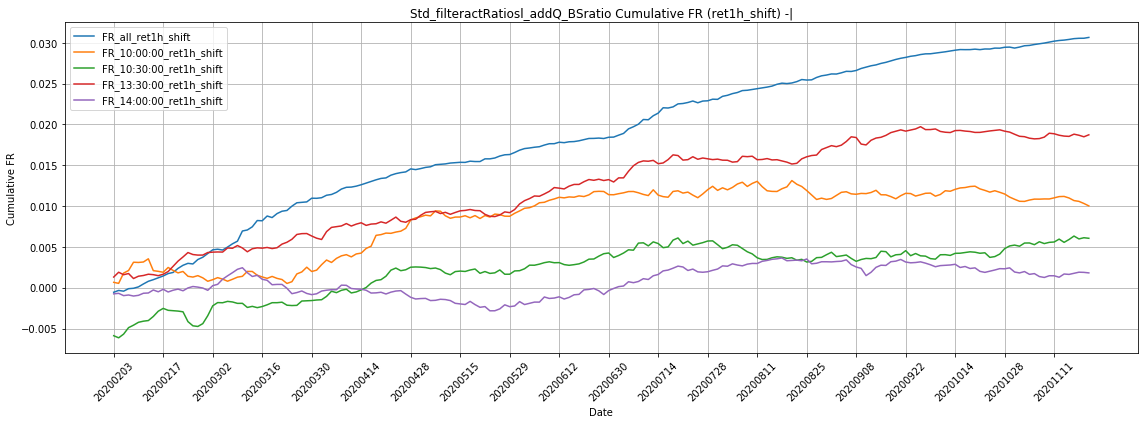

In [17]:
# raise Exception('pls')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_cols(feat_col):
    # # 假设你已经有以下变量
    # feat_col = 'Around3s_AvgPrc_minusclose'
    ret_cols = ['ret0e_shift', 'ret1h_shift']
    time_points = ['10:00:00', '10:30:00', '13:30:00', '14:00:00']

    df = feature_all_df.reset_index()

    # ---------- 全部时间点 (FR_all_*) ----------
    fr_all_results = {}
    for ret_col in ret_cols:
        sub_df = df[[feat_col, ret_col, 'date']].dropna()

        # 按date groupby，计算 FR = cov(x, y) / std(x)
        grouped = sub_df.groupby('date')
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
        std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_all_results[f'FR_all_{ret_col}'] = fr

    # ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
    fr_time_results = {}

    for tp in time_points:
        df_tp = df[df['time'] == tp].dropna(subset=[feat_col] + ret_cols)
        for ret_col in ret_cols:
            grouped = df_tp.groupby('date')
            x = df_tp[feat_col]
            y = df_tp[ret_col]
            mean_x = grouped[feat_col].transform('mean')
            mean_y = grouped[ret_col].transform('mean')
            std_x = grouped[feat_col].transform('std')

            cov_xy = ((x - mean_x) * (y - mean_y)).groupby(df_tp['date']).mean()
            std_x_daily = std_x.groupby(df_tp['date']).first()

            fr = cov_xy / std_x_daily.replace(0, np.nan)
            fr_time_results[f'FR_{tp}_{ret_col}'] = fr

    # 合并所有结果
    fr_all_df = pd.DataFrame(fr_all_results)
    fr_time_df = pd.DataFrame(fr_time_results)
    fr_df = pd.concat([fr_all_df, fr_time_df], axis=1)

    # 计算 cumulative FR
    cumulative_fr_df = fr_df.cumsum()


    # 分别提取 ret0e 和 ret1h 的 FR 列
    fr_0e_cols = [col for col in cumulative_fr_df.columns if 'ret0e_shift' in col]
    fr_1h_cols = [col for col in cumulative_fr_df.columns if 'ret1h_shift' in col]

    # 画 ret0e_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_0e_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (ret0e_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

    # 画 ret1h_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_1h_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (ret1h_shift) -|')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()
#     fr_df.to_parquet(f'/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/fr_save/{feat_col}.parquet', engine="pyarrow", compression="snappy")
    
for feat_col in  ['Mean_filteractdelayl_addQ_BSratio',
    'Sum_filteract_B_delayl_addQ_divall_trd',
    'Std_filteract_S_delayl_addQ_divall_real',
    'Std_filteractdelayl_addQ_BSdivall',
    'Std_filteractRatiosl_addQ_BSratio']:
    plot_cols(feat_col)